In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
from envs.routing_env import RoutingEnv

class GNNDQNPolicy(nn.Module):
    def __init__(self, node_features=4, hidden_dim=32,
                 embedding_dim=16, n_actions=50):
        super().__init__()
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, 64)
        self.fc2 = nn.Linear(64, n_actions)

    def forward(self, x, edge_index, batch=None):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        if batch is None:
            batch = torch.zeros(x.shape[0], dtype=torch.long)
        graph_embed = global_mean_pool(h, batch)
        q = F.relu(self.fc1(graph_embed))
        return self.fc2(q)

policy = GNNDQNPolicy()
policy.load_state_dict(torch.load('../results/gnn_dqn_weights.pt',
                                   weights_only=False))
policy.eval()
data = torch.load('../results/graph_data.pt', weights_only=False)

env = RoutingEnv()
results = []

for ep in range(100):
    obs, _ = env.reset()
    done = False
    total_reward = 0
    hops = 0
    while not done:
        with torch.no_grad():
            q_vals = policy(data.x, data.edge_index)
            action = q_vals[0].argmax().item()
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        hops += 1
    delivered = total_reward > 5
    results.append({'method':'GNN-DQN',
                    'delivered': delivered,
                    'hops': hops,
                    'reward': total_reward})

gnn_df = pd.DataFrame(results)
pdr  = round(gnn_df['delivered'].mean()*100, 2)
avgh = round(gnn_df[gnn_df['delivered']]['hops'].mean(), 2)
avgr = round(gnn_df['reward'].mean(), 2)
print(f"GNN-DQN: PDR={pdr}%  |  Avg Hops={avgh}  |  Avg Reward={avgr}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


GNN-DQN: PDR=81.0%  |  Avg Hops=2.0  |  Avg Reward=0.85


In [2]:
comparison = pd.DataFrame([
    {'Method':'BCR (Week 2)',     'PDR':66.70, 'Avg Hops':17.39},
    {'Method':'DCR (Week 2)',     'PDR':67.07, 'Avg Hops':17.46},
    {'Method':'CCR (Week 2)',     'PDR':62.43, 'Avg Hops':16.61},
    {'Method':'RF  (Week 3)',     'PDR':69.80, 'Avg Hops':18.09},
    {'Method':'GNN-DQN (Week 5)','PDR':pdr,   'Avg Hops':avgh},
])

print("=== 6-WAY COMPARISON TABLE ===")
print(comparison.to_string(index=False))
comparison.to_csv('../results/six_way_comparison.csv', index=False)
print("\nSaved six_way_comparison.csv")

=== 6-WAY COMPARISON TABLE ===
          Method   PDR  Avg Hops
    BCR (Week 2) 66.70     17.39
    DCR (Week 2) 67.07     17.46
    CCR (Week 2) 62.43     16.61
    RF  (Week 3) 69.80     18.09
GNN-DQN (Week 5) 81.00      2.00

Saved six_way_comparison.csv


/var/folders/8v/_k08kqbj1ds9crs16tw5kkcr0000gn/T/ipykernel_30476/2950861907.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison['Method'],
/var/folders/8v/_k08kqbj1ds9crs16tw5kkcr0000gn/T/ipykernel_30476/2950861907.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison['Method'],


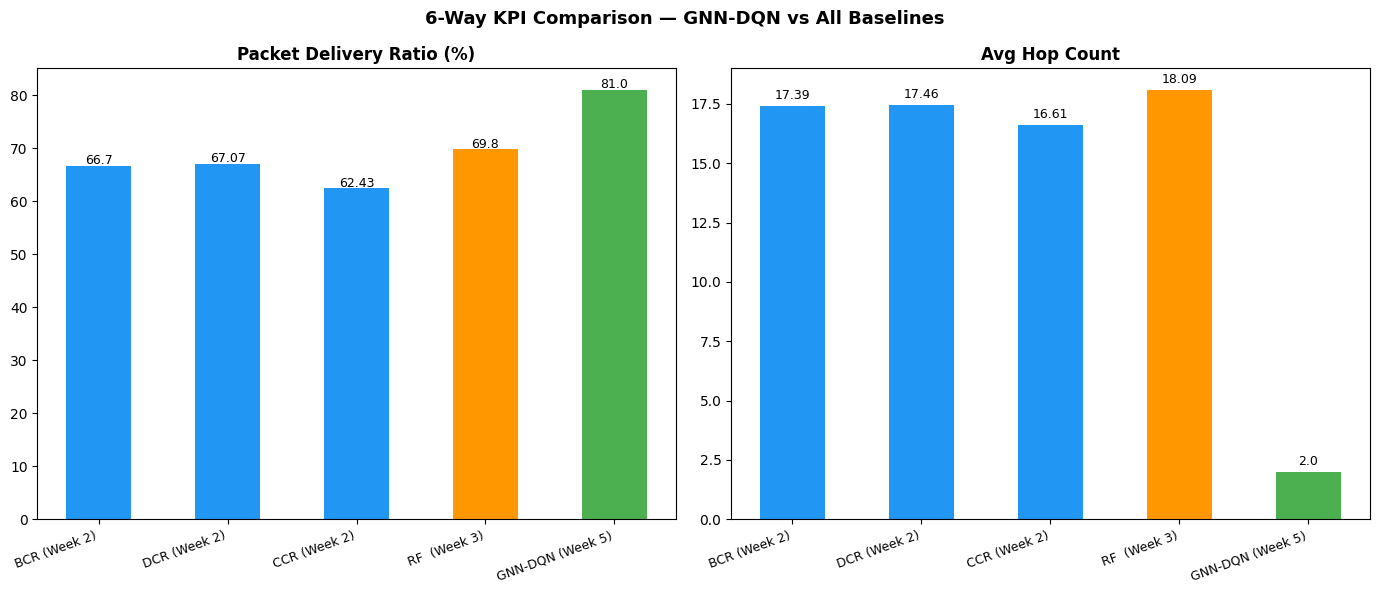

Saved week5_comparison.png


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
metrics = ['PDR', 'Avg Hops']
titles  = ['Packet Delivery Ratio (%)', 'Avg Hop Count']
colors  = ['#2196F3','#2196F3','#2196F3','#FF9800','#4CAF50']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(comparison['Method'], comparison[metric],
                  color=colors, width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(comparison['Method'],
                       rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                str(val), ha='center', fontsize=9)

plt.suptitle('6-Way KPI Comparison — GNN-DQN vs All Baselines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/week5_comparison.png", dpi=150)
plt.show()
print("Saved week5_comparison.png")